# Comparaison des erreurs — les deux finetunings (Prompt 1 vs Prompt 2)

Même structure d’analyse que le notebook par prompt, mais **les deux prompts** sont affichés dans les **mêmes tables** et les **mêmes graphiques** pour comparer directement baseline/finetuné sur Prompt 1 et Prompt 2.


## 1. Configuration et chemins


In [63]:
from pathlib import Path

NLI4CT_ROOT = Path(".").resolve()
if not (NLI4CT_ROOT / "results").exists():
    NLI4CT_ROOT = NLI4CT_ROOT / "NLI4CT"
if not (NLI4CT_ROOT / "results").exists():
    raise FileNotFoundError("Dossier results/ introuvable. Lancer le notebook depuis NLI4CT/ ou racine du dépôt.")

RESULTS_DIR_1 = NLI4CT_ROOT / "results" / "Prompt 1"
RESULTS_DIR_2 = NLI4CT_ROOT / "results" / "Prompt 2"
FIGURES_DIR = NLI4CT_ROOT / "results" / "compare_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

GOLD_TEST_JSON = NLI4CT_ROOT / "Gold_test.json"
GOLD_JSONL_1 = RESULTS_DIR_1 / "Gold_test_formatted_old_prompt.jsonl" if (RESULTS_DIR_1 / "Gold_test_formatted_old_prompt.jsonl").exists() else RESULTS_DIR_1 / "Gold_test_formatted.jsonl"
GOLD_JSONL_2 = RESULTS_DIR_2 / "Gold_test_formatted.jsonl"

csv_bl_1 = list(RESULTS_DIR_1.glob("pred_bl_*.csv"))
csv_ft_1 = list(RESULTS_DIR_1.glob("pred_ft_*.csv"))
# Prompt 2 : priorité aux bons fichiers (resultats_bl_NLI4CT / resultats_ft_NLI4CT)
CSV_BL_2 = RESULTS_DIR_2 / "predictions_a09a35458c702b33eeacc393d103063234e8bc28_job863970.csv"
CSV_FT_2 = RESULTS_DIR_2 / "predictions_qwen2_5_7b_finetuned_v2_job863969.csv"
if not CSV_BL_2.exists() or not CSV_FT_2.exists():
    csv_bl_2 = list(RESULTS_DIR_2.glob("pred_bl_*.csv"))
    csv_ft_2 = list(RESULTS_DIR_2.glob("pred_ft_*.csv"))
    CSV_BL_2 = csv_bl_2[0] if csv_bl_2 else None
    CSV_FT_2 = csv_ft_2[0] if csv_ft_2 else None
CSV_BL_1, CSV_FT_1 = (csv_bl_1[0] if csv_bl_1 else None), (csv_ft_1[0] if csv_ft_1 else None)

print("Prompt 1:", RESULTS_DIR_1, "| Baseline:", CSV_BL_1, "| Finetuné:", CSV_FT_1)
print("Prompt 2:", RESULTS_DIR_2, "| Baseline:", CSV_BL_2, "| Finetuné:", CSV_FT_2)
print("Figures:", FIGURES_DIR)


Prompt 1: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 1 | Baseline: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 1/pred_bl_qwen7b_NLI4CT_prompt1.csv | Finetuné: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 1/pred_ft_qwen7b_NLI4CT_prompt1.csv
Prompt 2: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 2 | Baseline: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 2/predictions_a09a35458c702b33eeacc393d103063234e8bc28_job863970.csv | Finetuné: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/Prompt 2/predictions_qwen2_5_7b_finetuned_v2_job863969.csv
Figures: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/compare_figures


In [64]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10


## 2. Chargement des données (Prompt 1 et Prompt 2)


In [65]:
def extract_premise_hypothesis(text):
    if "HYPOTHESIS:" not in text:
        return text[:800] if len(text) > 800 else text, text[:500] if len(text) > 500 else text
    before, after = text.split("HYPOTHESIS:", 1)
    premise = before.replace("PREMISE:", "").strip()
    for sep in (".\n\nAnswer", "?\n\nAnswer", "? Answer", "\n\nAnswer"):
        if sep in after: after = after.split(sep)[0]
    return premise, after.strip()

def load_one_prompt(csv_bl, csv_ft, jsonl_path):
    bl = pd.read_csv(csv_bl)
    ft = pd.read_csv(csv_ft)
    for df in (bl, ft):
        if df['is_correct'].dtype == object:
            df['is_correct'] = df['is_correct'].apply(lambda x: str(x).strip().lower() == 'true')
    meta_list = []
    with open(jsonl_path, 'r', encoding='utf-8') as f:
        for idx, line in enumerate(f):
            if not line.strip(): continue
            obj = json.loads(line)
            msgs = obj.get("messages", [])
            if len(msgs) < 2: continue
            user_content = ""
            for m in msgs:
                if m.get("role") == "user": user_content = m.get("content", "")
            prem, stmt = extract_premise_hypothesis(user_content)
            meta_list.append({'index': idx, 'premise_jsonl': prem, 'statement': stmt})
    df_meta = pd.DataFrame(meta_list)
    bl = bl.merge(df_meta, on='index', how='left')
    ft = ft.merge(df_meta, on='index', how='left')
    for df in (bl, ft):
        df['premise'] = df['premise_jsonl'].astype(str)
        df['hypothesis'] = df['statement'].astype(str)
        df['prompt_len'] = df['premise'].str.len() + df['hypothesis'].str.len()
    def safe_bin(s):
        q = s.quantile([0, 1/3, 2/3, 1]); e = np.sort(q.unique()); n = max(1, len(e)-1)
        if n == 1: return pd.Series('Moyen', index=s.index)
        return pd.cut(s, bins=e, labels=['Court','Moyen','Long'][:n], include_lowest=True)
    for df in (bl, ft): df['length_bin'] = safe_bin(df['prompt_len'])
    return bl, ft

assert CSV_BL_1 and CSV_FT_1 and CSV_BL_2 and CSV_FT_2, "Il manque des CSV (baseline ou finetuné) pour au moins un prompt."

df_bl_1, df_ft_1 = load_one_prompt(CSV_BL_1, CSV_FT_1, GOLD_JSONL_1)
df_bl_2, df_ft_2 = load_one_prompt(CSV_BL_2, CSV_FT_2, GOLD_JSONL_2)

if GOLD_TEST_JSON.exists():
    with open(GOLD_TEST_JSON, 'r', encoding='utf-8') as f: gold = json.load(f)
    keys = list(gold.keys())
    if len(keys) == len(df_bl_1):
        type_sec = pd.DataFrame([{'index': i, 'type': gold[keys[i]].get('Type','N/A'), 'section_id': gold[keys[i]].get('Section_id','N/A')} for i in range(len(keys))])
        for df in (df_bl_1, df_ft_1, df_bl_2, df_ft_2):
            df['type'] = type_sec.set_index('index').reindex(df['index'])['type'].values
            df['section_id'] = type_sec.set_index('index').reindex(df['index'])['section_id'].values

print("Prompt 1 — Baseline:", len(df_bl_1), "| Finetuné:", len(df_ft_1))
print("Prompt 2 — Baseline:", len(df_bl_2), "| Finetuné:", len(df_ft_2))


Prompt 1 — Baseline: 500 | Finetuné: 500
Prompt 2 — Baseline: 500 | Finetuné: 500


## 3. Statistiques globales


,Prompt 1 Baseline,Prompt 1 Finetuné,Prompt 2 Baseline,Prompt 2 Finetuné
0,0.6482,0.752526,0.661108,0.752167


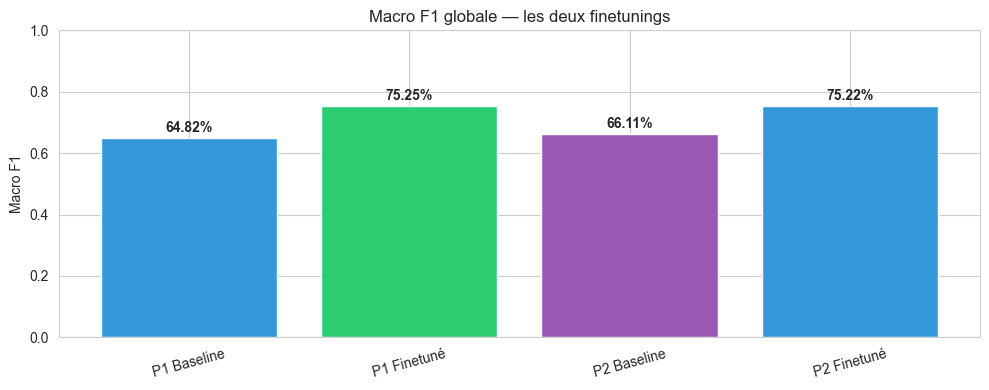

In [66]:
from sklearn.metrics import f1_score

def df_for_f1(df):
    """Exclut les prédictions UNKNOWN pour le macro F1 binaire (Entailment vs Contradiction uniquement)."""
    pred = df['predicted_label'].astype(str).str.strip().str.upper()
    return df[pred != 'UNKNOWN'].copy()

_bl1, _ft1 = df_for_f1(df_bl_1), df_for_f1(df_ft_1)
_bl2, _ft2 = df_for_f1(df_bl_2), df_for_f1(df_ft_2)
acc_dict = {
    'Prompt 1 Baseline': [f1_score(_bl1['true_label'], _bl1['predicted_label'], average='macro', zero_division=0)],
    'Prompt 1 Finetuné': [f1_score(_ft1['true_label'], _ft1['predicted_label'], average='macro', zero_division=0)],
    'Prompt 2 Baseline': [f1_score(_bl2['true_label'], _bl2['predicted_label'], average='macro', zero_division=0)],
    'Prompt 2 Finetuné': [f1_score(_ft2['true_label'], _ft2['predicted_label'], average='macro', zero_division=0)],
}
acc = pd.DataFrame(acc_dict)
display(acc)
fig, ax = plt.subplots(figsize=(10, 4))
cols = list(acc.columns)
n = len(cols)
x = np.arange(n)
vals = [acc[c].iloc[0] for c in cols]
labels = [c.replace('Prompt 1 ', 'P1 ').replace('Prompt 2 ', 'P2 ') for c in cols]
colors = ['#3498db', '#2ecc71', '#9b59b6', '#3498db', '#2ecc71', '#e67e22'][:n]
ax.bar(x, vals, color=colors)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1)
ax.set_title('Macro F1 globale — les deux finetunings')
for i, v in enumerate(vals): ax.text(i, v + 0.02, f'{v:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '01_accuracy_globale.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Analyse par type de tâche (Single vs Comparison)


,P1 Baseline,P1 Finetuné,P2 Baseline,P2 Finetuné
type,,,,
Comparison,0.603845,0.732988,0.627673,0.733079
Single,0.695387,0.775313,0.698072,0.773573


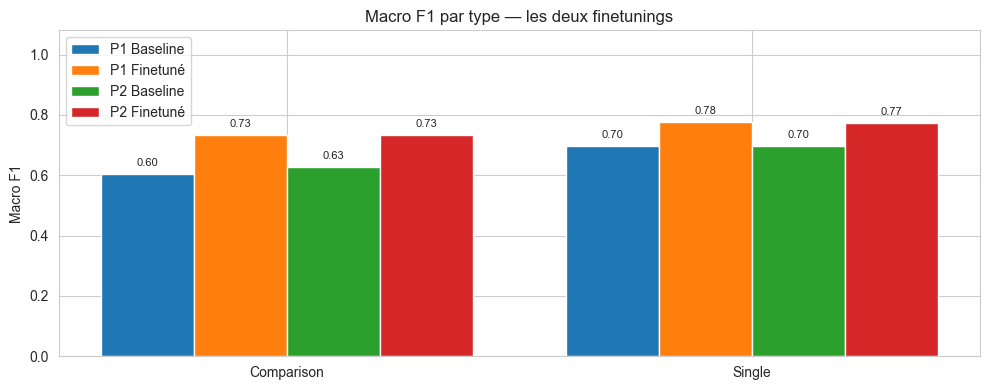

In [67]:
from sklearn.metrics import f1_score

def macro_f1_by(df, col):
    df = df_for_f1(df)
    def f1_group(g):
        if len(g) < 2: return np.nan
        return f1_score(g['true_label'], g['predicted_label'], average='macro', zero_division=0)
    res = df.groupby(col, observed=True).apply(f1_group, include_groups=False)
    n = df.groupby(col, observed=True).size()
    return pd.DataFrame({'n': n, 'macro_f1': res}).reset_index().set_index(col)

t1_bl = macro_f1_by(df_bl_1, 'type'); t1_ft = macro_f1_by(df_ft_1, 'type')
t2_bl = macro_f1_by(df_bl_2, 'type'); t2_ft = macro_f1_by(df_ft_2, 'type')
tab_type = pd.DataFrame({
    'P1 Baseline': t1_bl['macro_f1'], 'P1 Finetuné': t1_ft['macro_f1'],
    'P2 Baseline': t2_bl['macro_f1'], 'P2 Finetuné': t2_ft['macro_f1'],
})
display(tab_type)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(tab_type.index))
cols = list(tab_type.columns)
n_series = len(cols)
w = 0.8 / max(n_series, 1)
for i, c in enumerate(cols):
    x_pos = x + (i - n_series/2 + 0.5)*w
    ax.bar(x_pos, tab_type[c], w, label=c)
    for j, v in enumerate(tab_type[c]):
        if pd.notna(v): ax.text(x_pos[j], v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(tab_type.index)
ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1.08); ax.legend()
ax.set_title('Macro F1 par type — les deux finetunings')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '02_accuracy_par_type.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Analyse par section du protocole


,P1 Baseline,P1 Finetuné,P2 Baseline,P2 Finetuné
section_id,,,,
Adverse Events,0.710145,0.790955,0.681926,0.781145
Eligibility,0.634975,0.726583,0.607439,0.759245
Intervention,0.614685,0.745672,0.662980,0.739113
Results,0.630805,0.744167,0.689150,0.724429


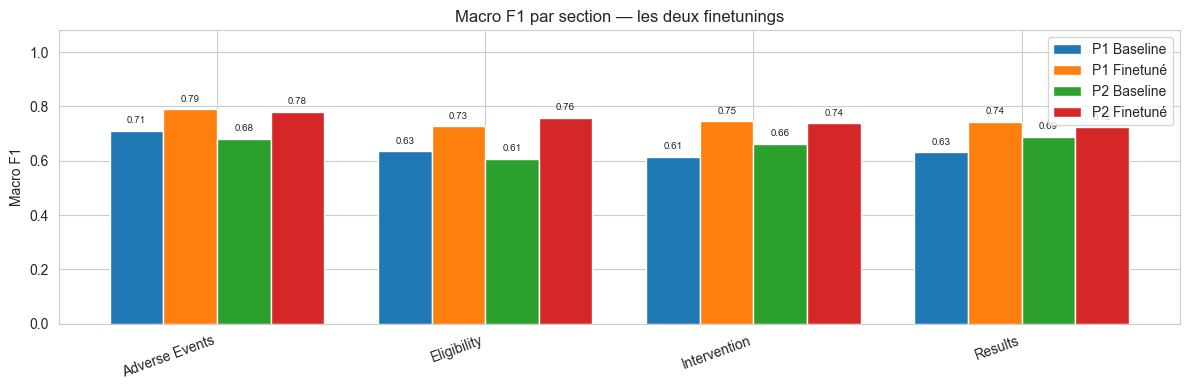

In [68]:
s1_bl = macro_f1_by(df_bl_1, 'section_id'); s1_ft = macro_f1_by(df_ft_1, 'section_id')
s2_bl = macro_f1_by(df_bl_2, 'section_id'); s2_ft = macro_f1_by(df_ft_2, 'section_id')
tab_sec = pd.DataFrame({
    'P1 Baseline': s1_bl['macro_f1'], 'P1 Finetuné': s1_ft['macro_f1'],
    'P2 Baseline': s2_bl['macro_f1'], 'P2 Finetuné': s2_ft['macro_f1'],
})
display(tab_sec)
fig, ax = plt.subplots(figsize=(12, 4))
x = np.arange(len(tab_sec.index)); cols = list(tab_sec.columns); n_series = len(cols); w = 0.8 / max(n_series, 1)
for i, c in enumerate(cols):
    x_pos = x + (i - n_series/2 + 0.5)*w
    ax.bar(x_pos, tab_sec[c], w, label=c)
    for j, v in enumerate(tab_sec[c]):
        if pd.notna(v): ax.text(x_pos[j], v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(tab_sec.index, rotation=20, ha='right')
ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1.08); ax.legend()
ax.set_title('Macro F1 par section — les deux finetunings')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '03_accuracy_par_section.png', dpi=150, bbox_inches='tight')
plt.show()


**Pourquoi le macro F1 global est bas alors que 3 sections sur 4 ont un bon F1 ?**

Le **macro F1 global** est calculé sur **toutes les données à la fois** (tous les exemples ensemble) : c’est la moyenne des F1 de chaque *classe* (Entailment, Contradiction) sur l’ensemble du jeu. Ce n’est **pas** la moyenne des quatre macro F1 par section.

Donc si une section a à la fois un **mauvais** F1 et **beaucoup d’exemples**, elle contribue davantage aux TP/FP/FN globaux et tire le macro F1 global vers le bas. La cellule ci‑dessous montre l’effectif par section et compare « moyenne des F1 par section » (une section = un vote) au « macro F1 global » (pondéré par le nombre d’exemples).

In [69]:
# Effectifs par section et comparaison F1 "moyenne des sections" vs F1 global
from sklearn.metrics import f1_score

counts = df_bl_1.groupby('section_id', observed=True).size()
print("Effectif par section (Prompt 1 Baseline):")
print(counts)
print()

# Macro F1 global (sur toutes les données, UNKNOWN exclus)
global_f1 = f1_score(df_for_f1(df_bl_1)['true_label'], df_for_f1(df_bl_1)['predicted_label'], average='macro', zero_division=0)
# Moyenne simple des macro F1 par section (chaque section compte autant)
mean_per_section_f1 = s1_bl['macro_f1'].mean()
print("P1 Baseline:")
print(f"  Macro F1 global (pondéré par les données) : {global_f1:.4f}")
print(f"  Moyenne des 4 macro F1 par section       : {mean_per_section_f1:.4f}")
print("  → La section avec le plus d'exemples (souvent Eligibility) pèse plus sur le global.")

Effectif par section (Prompt 1 Baseline):
section_id
Adverse Events    120
Eligibility       132
Intervention      142
Results           106
dtype: int64

P1 Baseline:
  Macro F1 global (pondéré par les données) : 0.6482
  Moyenne des 4 macro F1 par section       : 0.6477
  → La section avec le plus d'exemples (souvent Eligibility) pèse plus sur le global.


## 6. Analyse par longueur du prompt (court / moyen / long)


,P1 Baseline,P1 Finetuné,P2 Baseline,P2 Finetuné
length_bin,,,,
Court,0.712628,0.808376,0.691290,0.801941
Moyen,0.603384,0.734593,0.622727,0.725317
Long,0.618464,0.711779,0.668818,0.724311


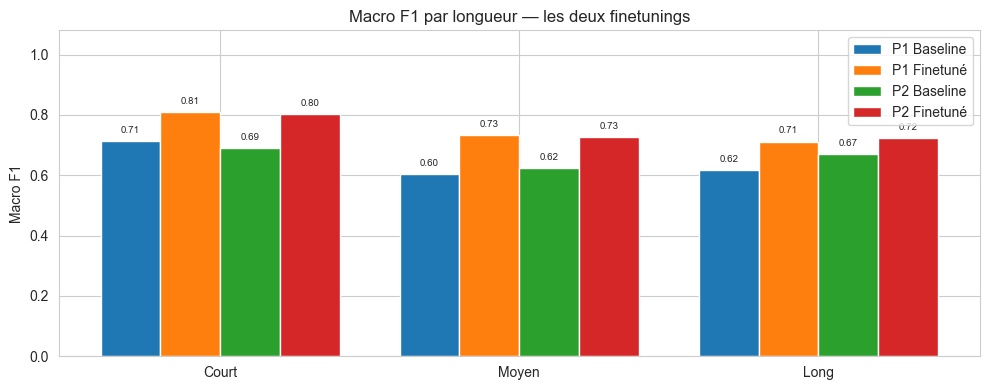

In [70]:
l1_bl = macro_f1_by(df_bl_1, 'length_bin'); l1_ft = macro_f1_by(df_ft_1, 'length_bin')
l2_bl = macro_f1_by(df_bl_2, 'length_bin'); l2_ft = macro_f1_by(df_ft_2, 'length_bin')
idx_len = l1_bl.index.union(l2_bl.index).union(l1_ft.index).union(l2_ft.index).unique()
tab_len = pd.DataFrame(index=idx_len, columns=['P1 Baseline','P1 Finetuné','P2 Baseline','P2 Finetuné'])
for col, ser in [('P1 Baseline', l1_bl['macro_f1']), ('P1 Finetuné', l1_ft['macro_f1']), ('P2 Baseline', l2_bl['macro_f1']), ('P2 Finetuné', l2_ft['macro_f1'])]:
    tab_len[col] = ser
tab_len = tab_len.fillna(0)
display(tab_len)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(tab_len)); cols = [c for c in tab_len.columns if c in tab_len]
n_series = len(cols); w = 0.8 / max(n_series, 1)
for i, c in enumerate(cols):
    x_pos = x + (i - n_series/2 + 0.5)*w
    ax.bar(x_pos, tab_len[c], w, label=c)
    for j, v in enumerate(tab_len[c]):
        if pd.notna(v) and v != 0: ax.text(x_pos[j], v + 0.02, f'{v:.2f}', ha='center', va='bottom', fontsize=7)
ax.set_xticks(x); ax.set_xticklabels(tab_len.index)
ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1.08); ax.legend()
ax.set_title('Macro F1 par longueur — les deux finetunings')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '04_accuracy_par_longueur.png', dpi=150, bbox_inches='tight')
plt.show()


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/2036036296.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g['macro_f1'] = df.groupby('len_bin_idx').apply(f1_bin)
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/2036036296.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g['macro_f1'] = df.groupby('len_bin_idx').apply(f1_bin)
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw

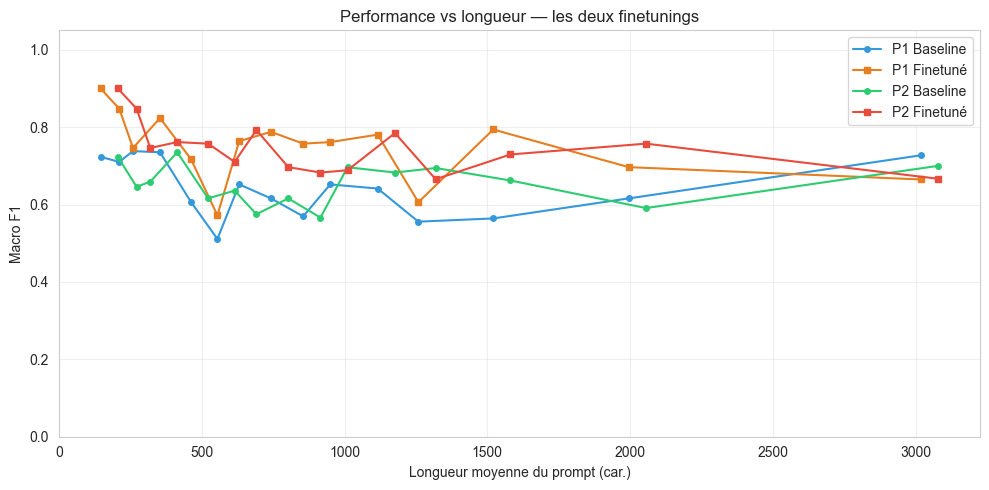

In [71]:
N_BINS = 15
for name, df in [('P1_bl', df_bl_1), ('P1_ft', df_ft_1), ('P2_bl', df_bl_2), ('P2_ft', df_ft_2)]:
    df['len_bin_idx'] = (df['prompt_len'].rank(pct=True, method='first') * N_BINS).astype(int).clip(0, N_BINS-1)
def curve(df):
    g = df.groupby('len_bin_idx').agg(len_moy=('prompt_len','mean'), n=('prompt_len','count'))
    g = g[g['n']>=1]
    def f1_bin(gr):
        if len(gr) < 2: return np.nan
        return f1_score(gr['true_label'], gr['predicted_label'], average='macro', zero_division=0)
    g['macro_f1'] = df.groupby('len_bin_idx').apply(f1_bin)
    return g.sort_index()
c1_bl, c1_ft = curve(df_for_f1(df_bl_1)), curve(df_for_f1(df_ft_1))
c2_bl, c2_ft = curve(df_for_f1(df_bl_2)), curve(df_for_f1(df_ft_2))
fig, ax = plt.subplots(figsize=(10, 5))
# Mêmes couleurs que les graphiques en barres : bleu, orange, vert, rouge
ax.plot(c1_bl['len_moy'], c1_bl['macro_f1'], 'o-', color='#3498db', label='P1 Baseline', markersize=4)
ax.plot(c1_ft['len_moy'], c1_ft['macro_f1'], 's-', color='#e67e22', label='P1 Finetuné', markersize=4)
ax.plot(c2_bl['len_moy'], c2_bl['macro_f1'], 'o-', color='#2ecc71', label='P2 Baseline', markersize=4)
ax.plot(c2_ft['len_moy'], c2_ft['macro_f1'], 's-', color='#e74c3c', label='P2 Finetuné', markersize=4)
ax.set_xlabel('Longueur moyenne du prompt (car.)'); ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Performance vs longueur — les deux finetunings')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '04b_accuracy_vs_longueur_courbe.png', dpi=150, bbox_inches='tight')
plt.show()


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/3149073203.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g['macro_f1'] = df.groupby('len_bin_idx').apply(f1_bin)
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/3149073203.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g['macro_f1'] = df.groupby('len_bin_idx').apply(f1_bin)
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw

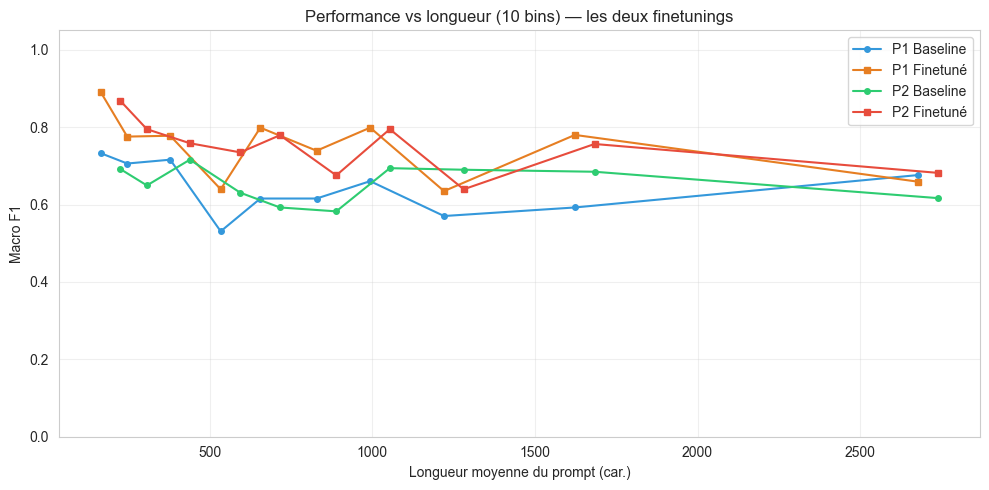

In [72]:
# Même graphique mais avec 10 bins (au lieu de 15)
N_BINS_10 = 10
for name, df in [('P1_bl', df_bl_1), ('P1_ft', df_ft_1), ('P2_bl', df_bl_2), ('P2_ft', df_ft_2)]:
    df['len_bin_idx'] = (df['prompt_len'].rank(pct=True, method='first') * N_BINS_10).astype(int).clip(0, N_BINS_10 - 1)
def curve(df):
    g = df.groupby('len_bin_idx').agg(len_moy=('prompt_len','mean'), n=('prompt_len','count'))
    g = g[g['n'] >= 1]
    def f1_bin(gr):
        if len(gr) < 2: return np.nan
        return f1_score(gr['true_label'], gr['predicted_label'], average='macro', zero_division=0)
    g['macro_f1'] = df.groupby('len_bin_idx').apply(f1_bin)
    return g.sort_index()
c1_bl_10, c1_ft_10 = curve(df_for_f1(df_bl_1)), curve(df_for_f1(df_ft_1))
c2_bl_10, c2_ft_10 = curve(df_for_f1(df_bl_2)), curve(df_for_f1(df_ft_2))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(c1_bl_10['len_moy'], c1_bl_10['macro_f1'], 'o-', color='#3498db', label='P1 Baseline', markersize=4)
ax.plot(c1_ft_10['len_moy'], c1_ft_10['macro_f1'], 's-', color='#e67e22', label='P1 Finetuné', markersize=4)
ax.plot(c2_bl_10['len_moy'], c2_bl_10['macro_f1'], 'o-', color='#2ecc71', label='P2 Baseline', markersize=4)
ax.plot(c2_ft_10['len_moy'], c2_ft_10['macro_f1'], 's-', color='#e74c3c', label='P2 Finetuné', markersize=4)
ax.set_xlabel('Longueur moyenne du prompt (car.)'); ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Performance vs longueur (10 bins) — les deux finetunings')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '04b_accuracy_vs_longueur_10bins.png', dpi=150, bbox_inches='tight')
plt.show()
# Réappliquer 15 bins pour les cellules suivantes si besoin
N_BINS = 15
for name, df in [('P1_bl', df_bl_1), ('P1_ft', df_ft_1), ('P2_bl', df_bl_2), ('P2_ft', df_ft_2)]:
    df['len_bin_idx'] = (df['prompt_len'].rank(pct=True, method='first') * N_BINS).astype(int).clip(0, N_BINS - 1)

/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/2720821913.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g['macro_f1'] = df.groupby('len_bin_fixed', observed=True).apply(f1_bin)
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/2720821913.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  g['macro_f1'] = df.groupby('len_bin_fixed', observed=True).apply(f1_bin)
/var/f

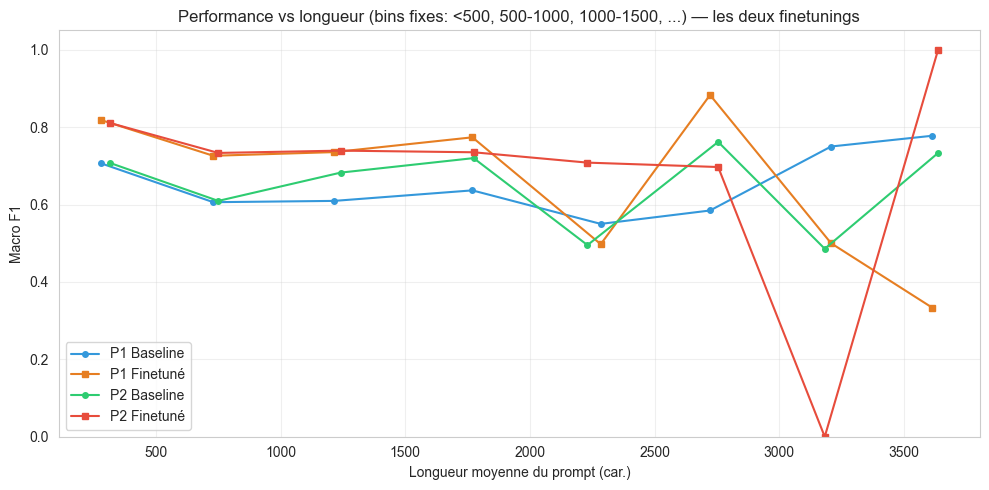

In [73]:
# Performance vs longueur avec bins fixes (moins de 500, 500-1000, 1000-1500, ...)
max_len = max(df_bl_1['prompt_len'].max(), df_ft_1['prompt_len'].max(), df_bl_2['prompt_len'].max(), df_ft_2['prompt_len'].max())
bins_fixed = list(range(0, int(max_len) + 501, 500))
labels_fixed = [f'{b}-{b+500}' for b in bins_fixed[:-1]]

def curve_fixed_bins(df, bins, labels):
    df = df.copy()
    df['len_bin_fixed'] = pd.cut(df['prompt_len'], bins=bins, labels=labels, include_lowest=True)
    g = df.groupby('len_bin_fixed', observed=True).agg(len_moy=('prompt_len','mean'), n=('prompt_len','count'))
    g = g[g['n'] >= 1]
    def f1_bin(gr):
        if len(gr) < 2: return np.nan
        return f1_score(gr['true_label'], gr['predicted_label'], average='macro', zero_division=0)
    g['macro_f1'] = df.groupby('len_bin_fixed', observed=True).apply(f1_bin)
    return g.sort_values('len_moy')

cf1_bl = curve_fixed_bins(df_for_f1(df_bl_1), bins_fixed, labels_fixed)
cf1_ft = curve_fixed_bins(df_for_f1(df_ft_1), bins_fixed, labels_fixed)
cf2_bl = curve_fixed_bins(df_for_f1(df_bl_2), bins_fixed, labels_fixed)
cf2_ft = curve_fixed_bins(df_for_f1(df_ft_2), bins_fixed, labels_fixed)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cf1_bl['len_moy'], cf1_bl['macro_f1'], 'o-', color='#3498db', label='P1 Baseline', markersize=4)
ax.plot(cf1_ft['len_moy'], cf1_ft['macro_f1'], 's-', color='#e67e22', label='P1 Finetuné', markersize=4)
ax.plot(cf2_bl['len_moy'], cf2_bl['macro_f1'], 'o-', color='#2ecc71', label='P2 Baseline', markersize=4)
ax.plot(cf2_ft['len_moy'], cf2_ft['macro_f1'], 's-', color='#e74c3c', label='P2 Finetuné', markersize=4)
ax.set_xlabel('Longueur moyenne du prompt (car.)'); ax.set_ylabel('Macro F1'); ax.set_ylim(0, 1.05)
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_title('Performance vs longueur (bins fixes: <500, 500-1000, 1000-1500, ...) — les deux finetunings')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '04b_accuracy_vs_longueur_bins_fixes.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Quand le modèle se trompe (matrices d'erreurs)


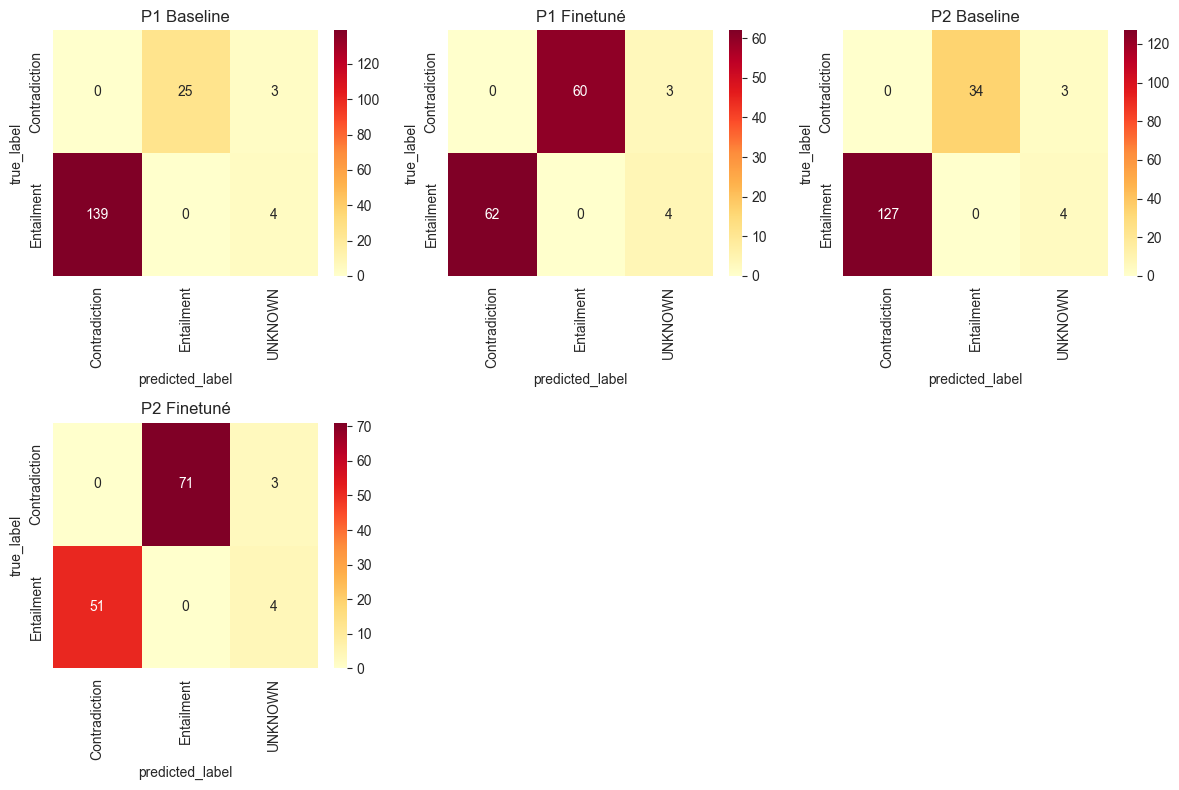

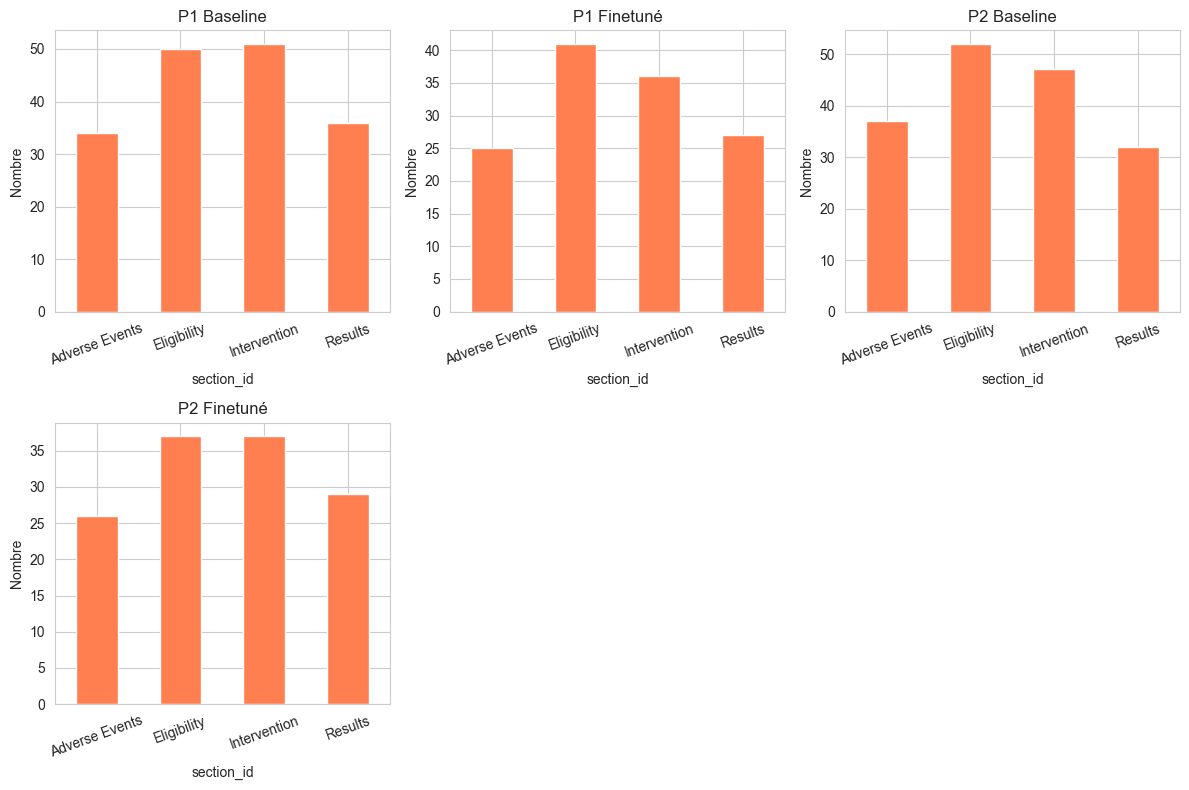

In [74]:
err_bl_1 = df_bl_1[~df_bl_1['is_correct']]
err_ft_1 = df_ft_1[~df_ft_1['is_correct']]
err_bl_2 = df_bl_2[~df_bl_2['is_correct']]
err_ft_2 = df_ft_2[~df_ft_2['is_correct']]
pairs = [(err_bl_1,'P1 Baseline'), (err_ft_1,'P1 Finetuné'), (err_bl_2,'P2 Baseline'), (err_ft_2,'P2 Finetuné')]
n_plots = len(pairs); ncol = 3; nrow = max(1, (n_plots + ncol - 1) // ncol)
fig, axes = plt.subplots(nrow, ncol, figsize=(4*ncol, 4*nrow)); axes = np.atleast_2d(axes)
axes_flat = axes.flatten()
for ax, (err, title) in zip(axes_flat, pairs):
    if len(err) > 0:
        c = err.groupby('true_label')['predicted_label'].value_counts().unstack(fill_value=0)
        sns.heatmap(c, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
    ax.set_title(title)
for j in range(len(pairs), len(axes_flat)): axes_flat[j].set_visible(False)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '05_erreurs_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, axes2 = plt.subplots(nrow, ncol, figsize=(4*ncol, 4*nrow)); axes2 = np.atleast_2d(axes2)
axes2_flat = axes2.flatten()
for ax, (err, title) in zip(axes2_flat, pairs):
    if len(err) > 0: err.groupby('section_id').size().plot(kind='bar', ax=ax, color='coral')
    ax.set_title(title); ax.set_ylabel('Nombre'); ax.tick_params(axis='x', rotation=20)
for j in range(len(pairs), len(axes2_flat)): axes2_flat[j].set_visible(False)
plt.tight_layout()
fig2.savefig(FIGURES_DIR / '06_erreurs_par_section.png', dpi=150, bbox_inches='tight')
plt.show()


### 7b. Cas où le modèle n'a pas produit un label reconnu (UNKNOWN)


In [75]:
unk = []
unk_models = [(df_bl_1,'P1 Baseline'), (df_ft_1,'P1 Finetuné'), (df_bl_2,'P2 Baseline'), (df_ft_2,'P2 Finetuné')]
for df, name in unk_models:
    u = df[df['predicted_label']=='UNKNOWN']
    if len(u) > 0: unk.append(u[['index','true_label','type','section_id']].assign(model=name))
if unk:
    unk_df = pd.concat(unk, ignore_index=True)
    display(unk_df.groupby('model').size().to_frame('nb_UNKNOWN'))
    unk_df.to_csv(FIGURES_DIR / 'cas_unknown_compare.csv', index=False)
    print('Exporté:', FIGURES_DIR / 'cas_unknown_compare.csv')
else: print('Aucun cas UNKNOWN.')


,nb_UNKNOWN
model,
P1 Baseline,7
P1 Finetuné,7
P2 Baseline,7
P2 Finetuné,7


Exporté: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/compare_figures/cas_unknown_compare.csv


## 8. Accord / désaccord entre les deux finetunings (P1 Finetuné vs P2 Finetuné)

On compare **P1 Finetuné** et **P2 Finetuné** pour voir s'ils se trompent **en même temps** ou non. Visualisation par **pattern d'accord** (les 2 corrects, les 2 en erreur, ou cas mixtes).


,Pattern,Effectif
pattern,,
11,Les 2 corrects,333
00,Les 2 en erreur,91
10,P1✓ P2✗,38
01,P1✗ P2✓,38


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/4212883705.py:19: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/4212883705.py:19: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/4212883705.py:20: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.savefig(FIGURES_DIR / '08_accord_deux_finetunings.png', dpi=150, bbox_inches='tight')
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/4212883705.py:20: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.savefig(FIGURES_DIR / '08_accord_deux_finetunings.png', dpi=150, bbox_inches='tight')
/Users/lubin/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.

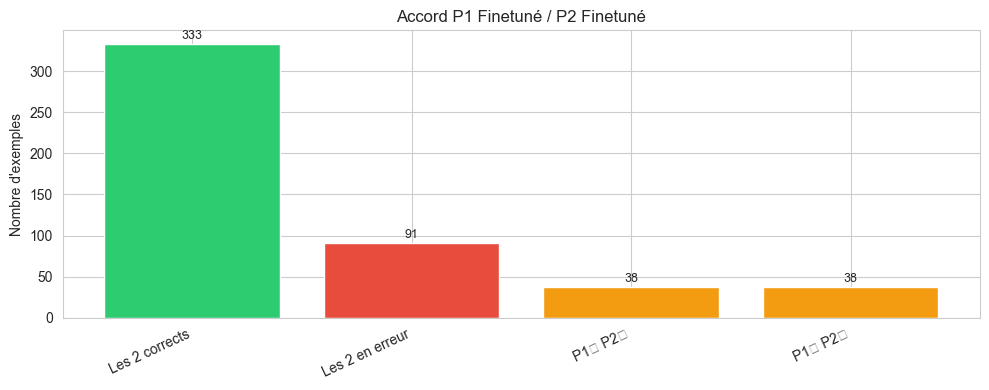

In [76]:
# Aligner les deux finetunings sur le même index (celui du gold)
idx_common = df_ft_1['index'].values
acc = pd.DataFrame({'index': idx_common})
acc['P1_ft'] = df_ft_1.set_index('index').reindex(idx_common)['is_correct'].values
acc['P2_ft'] = df_ft_2.set_index('index').reindex(idx_common)['is_correct'].values
acc_2 = acc[['index','P1_ft','P2_ft']].dropna()
acc_2 = acc_2.fillna(False)
acc_2['pattern'] = acc_2['P1_ft'].astype(int).astype(str) + acc_2['P2_ft'].astype(int).astype(str)
pattern_labels = {'11': 'Les 2 corrects', '00': 'Les 2 en erreur', '10': 'P1✓ P2✗', '01': 'P1✗ P2✓'}
counts = acc_2['pattern'].value_counts().reindex(list(pattern_labels.keys())).fillna(0).astype(int)
tab_accord = pd.DataFrame({'Pattern': [pattern_labels.get(p, p) for p in counts.index], 'Effectif': counts.values}, index=counts.index)
display(tab_accord)
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(tab_accord)); colors_bar = ['#2ecc71' if '2 corrects' in str(l) or l=='Les 2 corrects' else '#e74c3c' if '2 en erreur' in str(l) or l=='Les 2 en erreur' else '#f39c12' for l in tab_accord['Pattern']]
ax.bar(x, tab_accord['Effectif'], color=colors_bar)
for i, v in enumerate(tab_accord['Effectif']): ax.text(i, v + 2, str(int(v)), ha='center', va='bottom', fontsize=9)
ax.set_xticks(x); ax.set_xticklabels(tab_accord['Pattern'], rotation=25, ha='right')
ax.set_ylabel("Nombre d'exemples"); ax.set_title('Accord P1 Finetuné / P2 Finetuné')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '08_accord_deux_finetunings.png', dpi=150, bbox_inches='tight')
plt.show()


## 8b. Comparaison deux-à-deux (P1 Finetuné vs P2 Finetuné)

Accord **P1 Finetuné vs P2 Finetuné** : les deux corrects, P1 correct P2 faux, P1 faux P2 correct, les deux en erreur.

,Effectif
Label,
Les deux corrects,333
"P1 correct, P2 faux",38
"P1 faux, P2 correct",38
Les deux en erreur,91


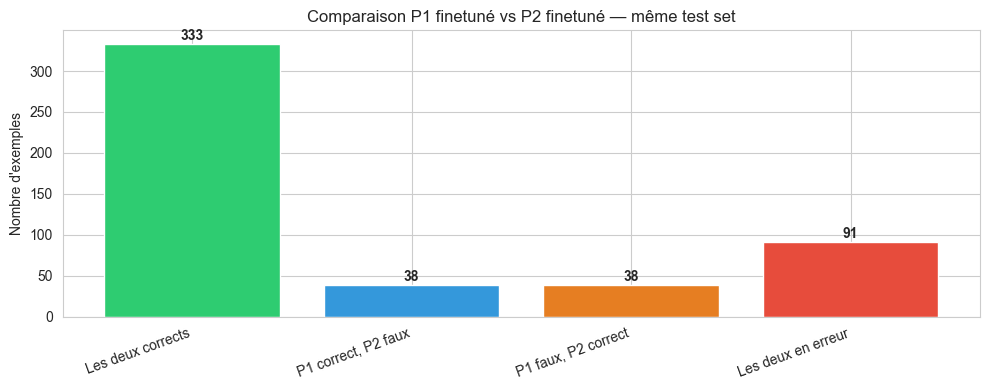

,Label,Effectif
0,Les deux corrects,333
1,P1 FT ✓ P2 FT ✗,38
2,P1 FT ✗ P2 FT ✓,38
3,Les deux en erreur,91


/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/4249473712.py:47: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/4249473712.py:47: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/4249473712.py:48: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.savefig(FIGURES_DIR / '08b_pairwise_accord.png', dpi=150, bbox_inches='tight')
/var/folders/71/b1s1b9y50596_3t1fgw_1dzw0000gn/T/ipykernel_97595/4249473712.py:48: UserWarning: Glyph 10007 (\N{BALLOT X}) missing from font(s) Arial.
  fig.savefig(FIGURES_DIR / '08b_pairwise_accord.png', dpi=150, bbox_inches='tight')
/Users/lubin/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) Arial.
  fig.canvas.print_f

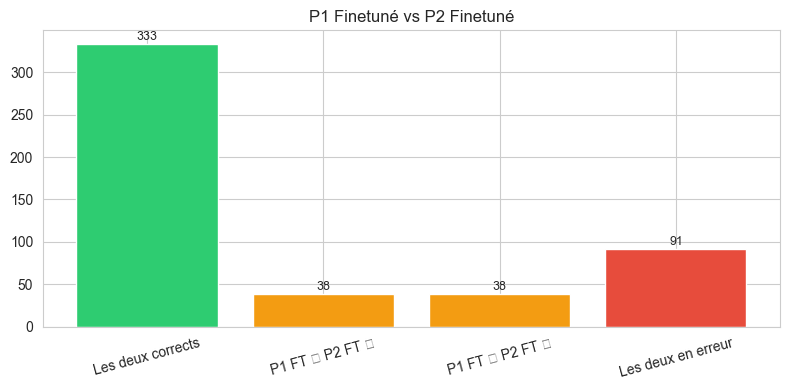

In [77]:
# P1 finetuné vs P2 finetuné (même index = même exemple)
ok_p1 = df_ft_1['is_correct'].values
ok_p2 = df_ft_2['is_correct'].values
# Tableau croisé : les deux corrects / P1 seul / P2 seul / les deux en erreur
both_ok = (ok_p1 & ok_p2).sum()
p1_ok_p2_ko = (ok_p1 & ~ok_p2).sum()
p1_ko_p2_ok = (~ok_p1 & ok_p2).sum()
both_ko = (~ok_p1 & ~ok_p2).sum()
tab_cross = pd.DataFrame({
    'Effectif': [both_ok, p1_ok_p2_ko, p1_ko_p2_ok, both_ko],
    'Label': ['Les deux corrects', 'P1 correct, P2 faux', 'P1 faux, P2 correct', 'Les deux en erreur']
})
tab_cross = tab_cross.set_index('Label')
display(tab_cross)
# Graphique en barres
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(4)
colors = ['#2ecc71', '#3498db', '#e67e22', '#e74c3c']
ax.bar(x, tab_cross['Effectif'], color=colors)
ax.set_xticks(x)
ax.set_xticklabels(tab_cross.index, rotation=20, ha='right')
ax.set_ylabel("Nombre d'exemples")
ax.set_title('Comparaison P1 finetuné vs P2 finetuné — même test set')
for i, v in enumerate(tab_cross['Effectif']): ax.text(i, v + 5, str(int(v)), ha='center', fontweight='bold')
plt.tight_layout()
fig.savefig(FIGURES_DIR / '08b_compare_ft_p1_vs_p2.png', dpi=150, bbox_inches='tight')
plt.show()

# Cas où les DEUX se trompent : intersection des erreurs
def pairwise_accord(df_a, df_b, name_a, name_b):
    common = list(set(df_a['index']) & set(df_b['index']))
    ok_a = df_a.set_index('index').loc[common, 'is_correct']
    ok_b = df_b.set_index('index').loc[common, 'is_correct']
    both_ok = (ok_a & ok_b).sum()
    a_ok_b_ko = (ok_a & ~ok_b).sum()
    a_ko_b_ok = (~ok_a & ok_b).sum()
    both_ko = ((~ok_a) & (~ok_b)).sum()
    return pd.DataFrame({'Label': [f'Les deux corrects', f'{name_a} ✓ {name_b} ✗', f'{name_a} ✗ {name_b} ✓', 'Les deux en erreur'], 'Effectif': [both_ok, a_ok_b_ko, a_ko_b_ok, both_ko]})

pair_P1_P2 = pairwise_accord(df_ft_1, df_ft_2, 'P1 FT', 'P2 FT')
display(pair_P1_P2)
fig, ax = plt.subplots(figsize=(8, 4))
bars_x = np.arange(len(pair_P1_P2)); ax.bar(bars_x, pair_P1_P2['Effectif'], color=['#2ecc71','#f39c12','#f39c12','#e74c3c'])
for i, v in enumerate(pair_P1_P2['Effectif']): ax.text(i, v + 2, str(int(v)), ha='center', va='bottom', fontsize=9)
ax.set_xticks(bars_x); ax.set_xticklabels(pair_P1_P2['Label'], rotation=15)
ax.set_title('P1 Finetuné vs P2 Finetuné'); ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
fig.savefig(FIGURES_DIR / '08b_pairwise_accord.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Cas où les 2 finetunings se trompent

Focus sur les **erreurs** : exemples où **P1 Finetuné et P2 Finetuné** se trompent en même temps, et répartition par section/type.


,Les 2 en erreur
0,91


,index,type,section_id,true_label,pred_P1,pred_P2
21,21,Single,Adverse Events,Contradiction,Entailment,Entailment
24,24,Comparison,Eligibility,Contradiction,Entailment,Entailment
43,43,Comparison,Results,Contradiction,Entailment,Entailment
48,48,Comparison,Adverse Events,Contradiction,Entailment,Entailment
52,52,Comparison,Results,Entailment,Contradiction,Contradiction
54,54,Comparison,Intervention,Contradiction,Entailment,Entailment
56,56,Single,Intervention,Entailment,Contradiction,Contradiction
60,60,Comparison,Eligibility,Entailment,UNKNOWN,UNKNOWN
69,69,Single,Results,Contradiction,Entailment,Entailment
76,76,Comparison,Eligibility,Contradiction,Entailment,Entailment


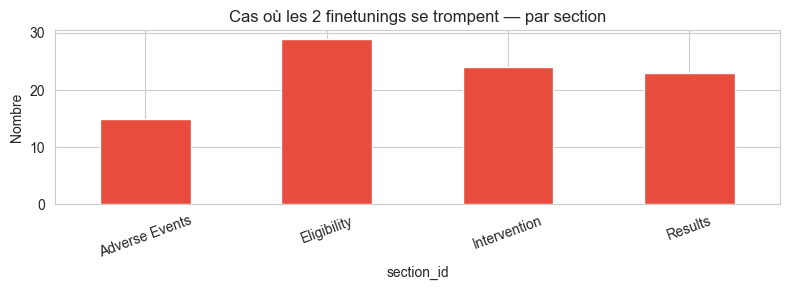

Exporté: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/compare_figures/two_finetunings_wrong.csv


In [78]:
# Cas où les 2 finetunings se trompent
two_wrong = acc_2[acc_2['pattern']=='00']
tab_err = pd.DataFrame({'Les 2 en erreur': [len(two_wrong)]})
display(tab_err)
if len(two_wrong) > 0:
    detail_2wrong = df_ft_1[df_ft_1['index'].isin(two_wrong['index'])][['index','type','section_id','true_label']].copy()
    idx_p1 = df_ft_1.set_index('index'); idx_p2 = df_ft_2.set_index('index')
    detail_2wrong['pred_P1'] = detail_2wrong['index'].map(idx_p1['predicted_label'])
    detail_2wrong['pred_P2'] = detail_2wrong['index'].map(idx_p2['predicted_label'])
    display(detail_2wrong.head(15))
    by_sec = detail_2wrong.groupby('section_id').size()
    fig, ax = plt.subplots(figsize=(8, 3))
    by_sec.plot(kind='bar', ax=ax, color='#e74c3c')
    ax.set_title('Cas où les 2 finetunings se trompent — par section'); ax.set_ylabel('Nombre'); ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '09_two_wrong_by_section.png', dpi=150, bbox_inches='tight')
    plt.show()
    detail_2wrong.to_csv(FIGURES_DIR / 'two_finetunings_wrong.csv', index=False)
    print('Exporté:', FIGURES_DIR / 'two_finetunings_wrong.csv')
else:
    print('Aucun exemple où les 2 finetunings se trompent.')


## 10. Cas où les 2 finetunings ont raison (accord total)

Focus sur les **succès communs** : exemples où **P1 Finetuné et P2 Finetuné** répondent correctement.


,Les 2 corrects
0,333


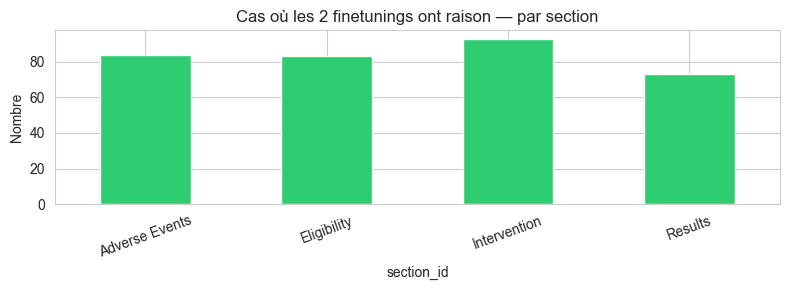

In [79]:
# Cas où les 2 finetunings ont raison
two_ok = acc_2[acc_2['pattern']=='11']
tab_ok = pd.DataFrame({'Les 2 corrects': [len(two_ok)]})
display(tab_ok)
if len(two_ok) > 0:
    detail_2ok = df_ft_1[df_ft_1['index'].isin(two_ok['index'])][['index','type','section_id']].copy()
    by_sec_ok = detail_2ok.groupby('section_id').size()
    fig, ax = plt.subplots(figsize=(8, 3))
    by_sec_ok.plot(kind='bar', ax=ax, color='#2ecc71')
    ax.set_title('Cas où les 2 finetunings ont raison — par section'); ax.set_ylabel('Nombre'); ax.tick_params(axis='x', rotation=20)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / '10_two_ok_by_section.png', dpi=150, bbox_inches='tight')
    plt.show()


### 10b. Exemples pour analyse (5 par cas)

On affiche **5 exemples aléatoires** pour deux situations :
1. **Les 2 finetunings se trompent** (P1 FT et P2 FT en erreur)
2. **Les 2 finetunings ont raison** (P1 FT et P2 FT corrects)


In [80]:
np.random.seed(42)
N_EX = 5
idx_p1 = df_ft_1.set_index('index')
idx_p2 = df_ft_2.set_index('index')
df_base = df_ft_1[['index','premise','hypothesis','true_label','type','section_id']].copy()
df_base['pred_P1_ft'] = df_base['index'].map(idx_p1['predicted_label'])
df_base['pred_P2_ft'] = df_base['index'].map(idx_p2['predicted_label'])

def show_examples(acc_subset, title, df_base):
    if len(acc_subset) == 0:
        print(f"{title}: aucun exemple.")
        return
    indices = acc_subset['index'].values
    sample = np.random.choice(indices, size=min(N_EX, len(indices)), replace=False)
    sub = df_base[df_base['index'].isin(sample)].set_index('index').loc[sample]
    print(f"\n{'='*60}")
    print(f"{title} ({len(indices)} exemples, {len(sample)} affichés)")
    print('='*60)
    for idx in sample:
        row = sub.loc[idx]
        prem = (row['premise'][:200] + '...') if len(str(row['premise'])) > 200 else row['premise']
        hyp = (row['hypothesis'][:150] + '...') if len(str(row['hypothesis'])) > 150 else row['hypothesis']
        print(f"\n--- Index {idx} (type={row['type']}, section={row['section_id']}) ---")
        print(f"Vrai label: {row['true_label']}")
        print(f"P1 Finetuné: {row['pred_P1_ft']} | P2 Finetuné: {row['pred_P2_ft']}")
        print(f"Premise: {prem}")
        print(f"Hypothesis: {hyp}")
    return

show_examples(acc_2[acc_2['pattern']=='00'], "1. Les 2 finetunings se trompent", df_base)
show_examples(acc_2[acc_2['pattern']=='11'], "2. Les 2 finetunings ont raison", df_base)

def repartition_par_cas(acc_subset, titre):
    if len(acc_subset) == 0:
        print(f"{titre}: aucun exemple.")
        return
    detail = df_ft_1[df_ft_1['index'].isin(acc_subset['index'])][['type','section_id']]
    print(f"\n--- {titre} (n={len(detail)}) ---")
    print("Par type:")
    display(pd.DataFrame(detail['type'].value_counts().rename_axis('type').reset_index(name='effectif')))
    print("Par section:")
    display(pd.DataFrame(detail['section_id'].value_counts().rename_axis('section_id').reset_index(name='effectif')))
    return

print("\n" + "="*60)
print("RÉPARTITION PAR TYPE ET PAR SECTION")
print("="*60)
repartition_par_cas(acc_2[acc_2['pattern']=='00'], "1. Les 2 se trompent")
repartition_par_cas(acc_2[acc_2['pattern']=='11'], "2. Les 2 ont raison")



1. Les 2 finetunings se trompent (91 exemples, 5 affichés)

--- Index 205 (type=Comparison, section=Eligibility) ---
Vrai label: Entailment
P1 Finetuné: UNKNOWN | P2 Finetuné: UNKNOWN
Premise: Inclusion Criteria:
  Written informed consent must have been obtained prior to any screening procedures
  Phase I part: Patients with advanced/metastatic solid tumors, with measurable or non-measurab...
Hypothesis: the secondary trial has the same inclusion/exclusion criteria for all participants, whereas the primary trial has 2 sets of inclusion criteria for the...

--- Index 134 (type=Comparison, section=Eligibility) ---
Vrai label: Contradiction
P1 Finetuné: UNKNOWN | P2 Finetuné: UNKNOWN
Premise: Inclusion Criteria:
  Written informed consent must have been obtained prior to any screening procedures
  Phase I part: Patients with advanced/metastatic solid tumors, with measurable or non-measurab...
Hypothesis: the secondary trial has the same inclusion/exclusion criteria for all participants,

,type,effectif
0,Comparison,51
1,Single,40


Par section:


,section_id,effectif
0,Eligibility,29
1,Intervention,24
2,Results,23
3,Adverse Events,15



--- 2. Les 2 ont raison (n=333) ---
Par type:


,type,effectif
0,Comparison,170
1,Single,163


Par section:


,section_id,effectif
0,Intervention,93
1,Adverse Events,84
2,Eligibility,83
3,Results,73


## 11. Exemples de régressions et d'améliorations


In [81]:
# Régressions / améliorations baseline vs finetuné (pour exemples)
reg1 = df_bl_1[df_bl_1['is_correct'] & ~df_ft_1['is_correct']]
imp1 = df_bl_1[~df_bl_1['is_correct'] & df_ft_1['is_correct']]
reg2 = df_bl_2[df_bl_2['is_correct'] & ~df_ft_2['is_correct']]
imp2 = df_bl_2[~df_bl_2['is_correct'] & df_ft_2['is_correct']]
N_EX = 3
for (reg, imp, df_ft, name) in [(reg1, imp1, df_ft_1, 'Prompt 1'), (reg2, imp2, df_ft_2, 'Prompt 2')]:
    print(f'=== {name} ===')
    print('--- Régressions (baseline correct, finetuné faux) ---')
    for _, row in reg.head(N_EX).iterrows():
        idx = row['index']
        ft_pred = df_ft.loc[df_ft['index'] == idx, 'predicted_label'].iloc[0]
        print(f"  index {idx}: Vrai={row['true_label']} | Baseline={row['predicted_label']} | Finetuné={ft_pred}")
    print('--- Améliorations (baseline faux, finetuné correct) ---')
    for _, row in imp.head(N_EX).iterrows():
        idx = row['index']
        ft_pred = df_ft.loc[df_ft['index'] == idx, 'predicted_label'].iloc[0]
        print(f"  index {idx}: Vrai={row['true_label']} | Baseline={row['predicted_label']} | Finetuné={ft_pred}")
    print()


=== Prompt 1 ===
--- Régressions (baseline correct, finetuné faux) ---
  index 1: Vrai=Entailment | Baseline=Entailment | Finetuné=Contradiction
  index 6: Vrai=Contradiction | Baseline=Contradiction | Finetuné=Entailment
  index 7: Vrai=Contradiction | Baseline=Contradiction | Finetuné=Entailment
--- Améliorations (baseline faux, finetuné correct) ---
  index 2: Vrai=Entailment | Baseline=Contradiction | Finetuné=Entailment
  index 10: Vrai=Contradiction | Baseline=Entailment | Finetuné=Contradiction
  index 11: Vrai=Entailment | Baseline=Contradiction | Finetuné=Entailment

=== Prompt 2 ===
--- Régressions (baseline correct, finetuné faux) ---
  index 18: Vrai=Entailment | Baseline=Entailment | Finetuné=Contradiction
  index 19: Vrai=Contradiction | Baseline=Contradiction | Finetuné=Entailment
  index 21: Vrai=Contradiction | Baseline=Contradiction | Finetuné=Entailment
--- Améliorations (baseline faux, finetuné correct) ---
  index 1: Vrai=Entailment | Baseline=Contradiction | Finet

## 12. Synthèse pour le rapport


In [82]:
lines = [
    '# Synthèse comparaison des deux finetunings (Prompt 1 vs Prompt 2)',
    '',
    '## Macro F1 globale',
    f"P1 Baseline: {f1_score(df_for_f1(df_bl_1)['true_label'], df_for_f1(df_bl_1)['predicted_label'], average='macro', zero_division=0):.2%} | P1 Finetuné: {f1_score(df_for_f1(df_ft_1)['true_label'], df_for_f1(df_ft_1)['predicted_label'], average='macro', zero_division=0):.2%}",
    f"P2 Baseline: {f1_score(df_for_f1(df_bl_2)['true_label'], df_for_f1(df_bl_2)['predicted_label'], average='macro', zero_division=0):.2%} | P2 Finetuné: {f1_score(df_for_f1(df_ft_2)['true_label'], df_for_f1(df_ft_2)['predicted_label'], average='macro', zero_division=0):.2%}",
    '',
    '## Régressions / Améliorations',
    f"P1 Régressions: {len(reg1)} | P1 Améliorations: {len(imp1)}",
    f"P2 Régressions: {len(reg2)} | P2 Améliorations: {len(imp2)}",
]
if 'two_wrong' in dir() and 'two_ok' in dir():
    lines.append(f"Les 2 finetunings en erreur: {len(two_wrong)} | Les 2 corrects: {len(two_ok)}")
synthese_path = FIGURES_DIR / 'synthese_compare.txt'
synthese_path.write_text('\n'.join(lines), encoding='utf-8')
print('\n'.join(lines))
print(f'\n>>> Synthèse sauvegardée: {synthese_path}')


# Synthèse comparaison des deux finetunings (Prompt 1 vs Prompt 2)

## Macro F1 globale
P1 Baseline: 64.82% | P1 Finetuné: 75.25%
P2 Baseline: 66.11% | P2 Finetuné: 75.22%

## Régressions / Améliorations
P1 Régressions: 60 | P1 Améliorations: 102
P2 Régressions: 64 | P2 Améliorations: 103
Les 2 finetunings en erreur: 91 | Les 2 corrects: 333

>>> Synthèse sauvegardée: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/compare_figures/synthese_compare.txt


## 13. Export des résultats détaillés


In [83]:
export = df_bl_1[['index','type','section_id']].copy()
export['P1_bl_correct'] = df_bl_1['is_correct'].values
export['P1_ft_correct'] = df_ft_1['is_correct'].values
export['P2_bl_correct'] = df_bl_2['is_correct'].values
export['P2_ft_correct'] = df_ft_2['is_correct'].values
export['prompt_len_p1'] = df_bl_1['prompt_len'].values
export['prompt_len_p2'] = df_bl_2['prompt_len'].values
out_csv = FIGURES_DIR / 'error_analysis_compare.csv'
export.to_csv(out_csv, index=False)
print(f'Résultats détaillés sauvegardés: {out_csv}')
print(f'Figures: {FIGURES_DIR}')


Résultats détaillés sauvegardés: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/compare_figures/error_analysis_compare.csv
Figures: /Users/lubin/Documents/NLI_Finetuning/NLI4CT/results/compare_figures
